In [ ]:
!pip install lightgbm scikit-learn imbalanced-learn shap optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 20.8 MB/s eta 0:00:00


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.6 MB/s eta 0:00:00


Importing required libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#basic ones
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from google.colab import drive
from tqdm.auto import tqdm
import shap
import seaborn as sns

#imblearn
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

#sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier)
from sklearn.model_selection import (LeaveOneOut, StratifiedKFold,
                                     RepeatedStratifiedKFold, learning_curve,
                                     permutation_test_score)
from sklearn.metrics import (roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, precision_recall_curve, average_precision_score)
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
from sklearn.inspection import permutation_importance


#models
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [ ]:
# Set this to True if using Google Colab
USE_COLAB = True

from pathlib import Path

if USE_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    DATA_ROOT = Path("/content/drive/MyDrive")
else:
    # Change this to your local dataset directory
    DATA_ROOT = Path("/path/to/GBA1_Project")

ALPHAMISSENSE_PARQUET = DATA_ROOT / "AlphaMissense.parquet"
DBNSFP_PARQUET = DATA_ROOT / "chr1.parquet"

In [ ]:
CSV_PATH   = f"{DATA_ROOT}/GBA1_Annotated_Final_With_Types.csv"
OUTPUT_CSV = f"{DATA_ROOT}/GBA1_Trajectory_Predictions.csv"

In [ ]:
df = pd.read_csv(CSV_PATH)

,chrom,pos,ref,alt,Consequence,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,...,MutPred2_pred,Intervar_class,Intervar_score,plddt,Dynamut2_ddg,Dynamut2_effect,GD1,GD2,GD3,residual_activity
0,1,155235002,C,G,missense_variant,c.1604G>C,p.Arg535Pro,1741,1604,535,...,UC,Likely pathogenic,3.0,97.62,-0.20,Destabilizing,0,0,0,NaN
1,1,155235002,C,T,missense_variant,c.1604G>A,p.Arg535His,1741,1604,535,...,BP,Likely pathogenic,3.0,97.62,-0.84,Destabilizing,1,1,1,5.0
2,1,155235003,G,A,missense_variant,c.1603C>T,p.Arg535Cys,1740,1603,535,...,BP,Uncertain significance,2.0,97.62,-0.50,Destabilizing,1,1,0,NaN
3,1,155235003,G,T,missense_variant,c.1603C>A,p.Arg535Ser,1740,1603,535,...,UC,Uncertain significance,2.0,97.62,-0.99,Destabilizing,0,0,0,NaN
4,1,155235005,C,T,missense_variant,c.1601G>A,p.Arg534His,1738,1601,534,...,BP,Uncertain significance,2.0,97.81,-0.58,Destabilizing,0,0,0,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
754,1,155241103,A,G,missense_variant,c.10T>C,p.Ser4Pro,147,10,4,...,BM,Uncertain significance,2.0,42.03,-0.25,Destabilizing,1,1,1,NaN
755,1,155241105,A,G,missense_variant,c.8T>C,p.Phe3Ser,145,8,3,...,BM,Uncertain significance,2.0,43.69,-0.62,Destabilizing,0,0,0,NaN
756,1,155241106,A,G,missense_variant,c.7T>C,p.Phe3Leu,144,7,3,...,BM,Uncertain significance,2.0,43.69,-0.82,Destabilizing,0,0,0,NaN
757,1,155241107,C,A,missense_variant,c.6G>T,p.Glu2Asp,143,6,2,...,BM,Uncertain significance,2.0,40.16,NaN,NaN,0,0,0,NaN


In [ ]:
df['gnomad_af'] = df['gnomad_af'].fillna(0.0)

In [ ]:
def assign_label(row):
    gd1, gd2, gd3 = int(row['GD1']), int(row['GD2']), int(row['GD3'])
    if (gd2 == 1 or gd3 == 1) and gd1 == 0: #neuronopathic
      return 1
    if gd1 == 1 and gd2 == 0 and gd3 == 0: #non-neuronopathic
      return 0
    return None

In [ ]:
df['trajectory_label'] = df.apply(assign_label, axis=1)

In [ ]:
df['residual_activity_known'] = df['residual_activity'].notna().astype(int)

#adding another column called residual_activity_known, which is 1 if data is present and 0 if not

In [ ]:
si = SimpleImputer(strategy='median')
df['residual_activity'] = si.fit_transform(df[['residual_activity']])

#only 52 variants have the residual_activity score data available, so replacing the once which are absent with the median value

Training Set:

Out of the 759 variants we have only 79 variants can be properly classified into Neuronopathic or Non-neuronopathic and hence only 79 will be included in the training set and we will make predictions on the remaining variants

In [ ]:
df_train = df[df['trajectory_label'].notna()].copy()
n_covered = df_train['residual_activity'].notna().sum()

# Class separation for residual activity
m0 = df_train[df_train['trajectory_label']==0]['residual_activity'].mean()
m1 = df_train[df_train['trajectory_label']==1]['residual_activity'].mean()

With various permutation and combinations, these were the top 6 factors which gave the best AUC score.

Since the dataset size is very small including to many columns in the FEATURE_COLS set will lead to overfitting

In [ ]:
FEATURE_COLS = [
    'plddt',               # strongest signal from separation analysis
    'Dynamut2_ddg',        # thermodynamic stability
    'CADD_score',          # overall deleteriousness
    'MutPred2_score',      # functional mechanism
    'SIFT_score',          # evolutionary constraint
    'residual_activity',   # enzyme activity
]

In [ ]:
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

df_train = df[df['trajectory_label'].notna()].copy()
X_train  = df_train[FEATURE_COLS].copy()
y_train  = df_train['trajectory_label'].astype(int)
X_all    = df[FEATURE_COLS].copy()

n_pos   = y_train.sum()
n_neg   = (y_train == 0).sum()
prior   = n_pos / len(y_train)

In [ ]:
print(f"\nTraining: {len(y_train)} variants ({n_neg} non-neuro, {n_pos} neuro)")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Prior P(neuro): {prior:.4f}")
print(f"\nMissing values:")
for col in FEATURE_COLS:
    n = X_train[col].isna().sum()
    if n > 0:
        print(f"  {col}: {n} NaN → SimpleImputer(median)")


Training: 79 variants (62 non-neuro, 17 neuro)
Features: 6
Prior P(neuro): 0.2152

Missing values:
  Dynamut2_ddg: 2 NaN → SimpleImputer(median)


Leave-One-Out Function

In [ ]:
def loo_auc(pipe, X, y):
    y = np.asarray(y)
    loo = LeaveOneOut()
    probs = np.empty(len(y))

    for tr, te in loo.split(X):
        model = clone(pipe)
        model.fit(
            X.iloc[tr],
            y[tr]
        )
        probs[te] = model.predict_proba(
            X.iloc[te]
        )[:,1]
    auc = roc_auc_score(y, probs)

    return auc, probs

Running LOO function to sort of find out which model gives better AUC

In [ ]:
n_ratio = n_neg / n_pos

CLASSIFIERS = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   LogisticRegression(
            C=0.1,
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        )),
    ]),

    'Linear SVM': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   SVC(
            kernel='linear',
            C=0.1,
            class_weight='balanced',
            probability=True,
            random_state=42
        )),
    ]),

    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   RandomForestClassifier(
            n_estimators=100,
            max_depth=3,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=42
        )),
    ]),

    'LightGBM': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   LGBMClassifier(
            num_leaves=8,
            max_depth=3,
            n_estimators=100,
            min_data_in_leaf=5,
            learning_rate=0.05,
            lambda_l1=0.5,
            lambda_l2=1.0,
            scale_pos_weight=n_ratio,
            objective='binary',
            verbose=-1,
            random_state=42
        )),
    ]),

'XGBoost': Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        max_depth=3,
        min_child_weight=5,
        n_estimators=100,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        gamma=0,
        scale_pos_weight=n_ratio,
        random_state=42,
        n_jobs=-1
    )),
]),


'CatBoost': Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', CatBoostClassifier(
        iterations=100,
        learning_rate=0.05,
        depth=3,

        l2_leaf_reg=3,

        auto_class_weights='Balanced',

        loss_function='Logloss',
        eval_metric='AUC',

        random_seed=42,
        verbose=False
    )),
]),



'AdaBoost': Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    )),
]),

  'RBF SVM': Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    )),
]),


  'HistGradientBoosting': Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=100,
        max_depth=3,
        min_samples_leaf=5,
        l2_regularization=1.0,
        random_state=42
    )),
]),


  'MLP': Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='adam',
        alpha=0.01,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    )),
]),
}


print("🔍 Comparing classifiers with Leave-One-Out CV...\n")
print(f"  {'Classifier':<22} {'AUC':>7}  Interpretation")
print("  " + "─" * 55)

loo_results = {}
for name, pipe in CLASSIFIERS.items():
    auc, probs = loo_auc(pipe, X_train, y_train)
    loo_results[name] =  {
        "auc": auc,
        "probas": probs
    }

    interpretation = (
        "🟢 good signal"  if auc > 0.70 else
        "🟡 weak signal"  if auc > 0.58 else
        "🔴 near-random"
    )
    print(f"  {name:<22} {auc:.4f}  {interpretation}")

best_name, best_info = max(loo_results.items(),key=lambda x: x[1]["auc"])
best_auc = loo_results[best_name]['auc']
best_pipe = CLASSIFIERS[best_name]

print(f"\n  Best: {best_name}  (AUC = {best_auc:.4f})")


🔍 Comparing classifiers with Leave-One-Out CV...

  Classifier                 AUC  Interpretation
  ───────────────────────────────────────────────────────
  Logistic Regression    0.7040  🟢 good signal
  Linear SVM             0.5455  🔴 near-random
  Random Forest          0.5285  🔴 near-random
  LightGBM               0.4810  🔴 near-random
  XGBoost                0.4810  🔴 near-random
  CatBoost               0.5294  🔴 near-random
  AdaBoost               0.5911  🟡 weak signal
  RBF SVM                0.7827  🟢 good signal
  HistGradientBoosting   0.4602  🔴 near-random
  MLP                    0.5882  🟡 weak signal

  Best: RBF SVM  (AUC = 0.7827)


Checking the significance i.e.., the AUC score we got is actually valid or not

In [ ]:
best_pipe = CLASSIFIERS[best_name]
real_auc, real_probas = loo_auc(
    best_pipe,
    X_train,
    y_train
)

rng = np.random.default_rng(42)
perm_aucs = []

for i in tqdm(range(500), desc="Permutation Test"):
    shuffled = rng.permutation(y_train)
    auc_perm, _ = loo_auc(
        best_pipe,
        X_train,
        shuffled
    )
    perm_aucs.append(auc_perm)
perm_aucs = np.array(perm_aucs)

#calculting the p value
pvalue = (np.sum(perm_aucs >= real_auc) + 1) / (len(perm_aucs) + 1)


print(f"Real LOOCV AUC : {real_auc:.4f}")
print(f"Mean permuted  : {perm_aucs.mean():.4f}")
print(f"Std permuted   : {perm_aucs.std():.4f}")
print(f"p-value        : {pvalue:.4f}")
print()
if pvalue < 0.05:
    print("  ✅ SIGNIFICANT (p < 0.05): real signal exists in these features.")
    print("     The model is learning something beyond random chance.")
    print("     AUC is limited by sample size, not by absence of signal.")
elif pvalue < 0.10:
    print("  ⚠️  MARGINAL (0.05 < p < 0.10): weak signal, borderline significance.")
    print("     More labeled data or better features would clarify this.")
else:
    print("  ❌ NOT SIGNIFICANT (p > 0.10): cannot distinguish from random.")
    print("     Current features do not contain sufficient information to")
    print("     separate neuronopathic from non-neuronopathic trajectories.")
    print("     This IS itself a publishable finding — see paper framing below.")

Permutation Test:   0%|          | 0/500 [00:00<?, ?it/s]

Real LOOCV AUC : 0.7827
Mean permuted  : 0.3882
Std permuted   : 0.2022
p-value        : 0.0160

  ✅ SIGNIFICANT (p < 0.05): real signal exists in these features.
     The model is learning something beyond random chance.
     AUC is limited by sample size, not by absence of signal.


In [ ]:
best_probas = real_probas

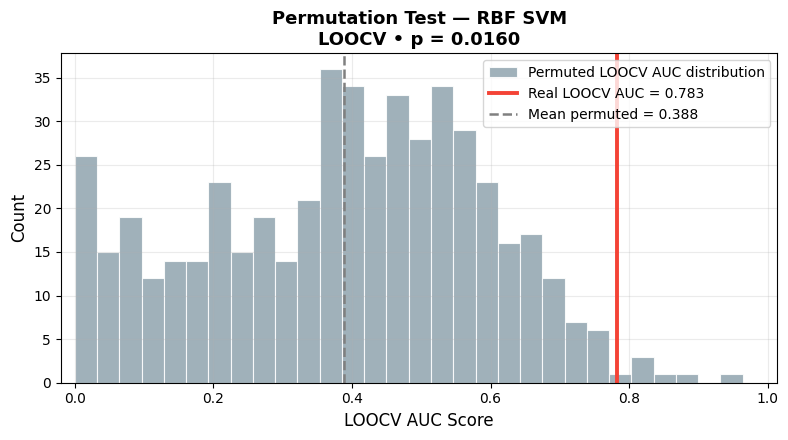

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# Histogram
ax.hist(
    perm_aucs,
    bins=30,
    color='#90A4AE',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85,
    label='Permuted LOOCV AUC distribution'
)

# Real AUC
ax.axvline(
    real_auc,
    color='#F44336',
    lw=2.8,
    label=f'Real LOOCV AUC = {real_auc:.3f}'
)

# Mean permutation AUC
ax.axvline(
    np.mean(perm_aucs),
    color='gray',
    lw=1.8,
    ls='--',
    label=f'Mean permuted = {np.mean(perm_aucs):.3f}'
)

# Cosmetics
ax.set_xlabel('LOOCV AUC Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(
    f'Permutation Test — {best_name}\n'
    f'LOOCV • p = {pvalue:.4f}',
    fontsize=13,
    weight='bold'
)

ax.grid(alpha=0.25)
ax.legend(fontsize=10, frameon=True)

# Add some padding so the red line isn't stuck to the border
ax.set_xlim(
    min(perm_aucs) - 0.02,
    max(real_auc, max(perm_aucs)) + 0.05
)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/permutation_test_loocv.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Training the final best model

In [ ]:
print(f"\n🚀 Training final {best_name} on all {len(y_train)} labeled variants...")
final_pipeline = Pipeline(CLASSIFIERS[best_name].steps)
final_pipeline.fit(X_train, y_train)
print("✅ Final model trained.")


🚀 Training final RBF SVM on all 79 labeled variants...
✅ Final model trained.


In [ ]:
fpr, tpr, thresholds = roc_curve(y_train, best_probas)

youden_j          = tpr - fpr
optimal_idx       = np.argmax(youden_j)
OPTIMAL_THRESHOLD = float(thresholds[optimal_idx])

print(f"Youden-optimal threshold: {OPTIMAL_THRESHOLD:.4f}")
print(f"At this threshold:")
print(f"  Sensitivity: {tpr[optimal_idx]:.3f}")
print(f"  Specificity: {1 - fpr[optimal_idx]:.3f}")
print(f"  Youden J:    {youden_j[optimal_idx]:.3f}")
print(f"  Prior:       {prior:.4f}")

Youden-optimal threshold: 0.2290
At this threshold:
  Sensitivity: 0.882
  Specificity: 0.790
  Youden J:    0.673
  Prior:       0.2152


In [ ]:
proba_all = final_pipeline.predict_proba(X_all)
df['prob_neuronopathic']     = proba_all[:, 1].round(4)
df['prob_non_neuronopathic'] = proba_all[:, 0].round(4)

def classify(p: float):
    if p >= OPTIMAL_THRESHOLD:
        return "Predicted Neuronopathic (Type 2/3-like)"
    elif p >= prior:
        return "Uncertain — Elevated Risk"
    else:
        return "Predicted Non-neuronopathic (Type 1-like)"

def conf(p): return round(abs(p - prior) / max(prior, 1 - prior), 4)

df['trajectory_class'] = df['prob_neuronopathic'].apply(classify)
df['confidence']       = df['prob_neuronopathic'].apply(conf)
df.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved: {OUTPUT_CSV}")
print(df['trajectory_class'].value_counts())

✅ Saved: /content/drive/MyDrive/GBA1_Trajectory_Predictions_V3.csv
trajectory_class
Predicted Non-neuronopathic (Type 1-like)    471
Predicted Neuronopathic (Type 2/3-like)      273
Uncertain — Elevated Risk                     15
Name: count, dtype: int64


Confusion Matrix and ROC Curve

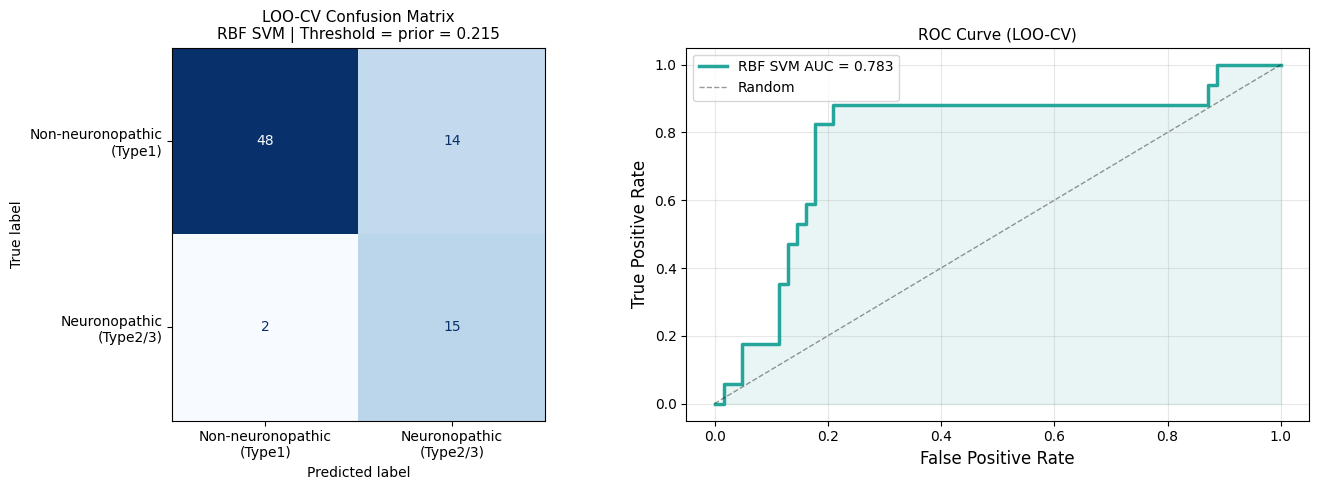

In [ ]:
y_pred  = (best_probas >= prior).astype(int)

cm   = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-neuronopathic\n(Type1)', 'Neuronopathic\n(Type2/3)']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(
    f'LOO-CV Confusion Matrix\n{best_name} | Threshold = prior = {prior:.3f}',
    fontsize=11)


axes[1].plot(fpr, tpr, color='#26A69A', lw=2.5,
             label=f'{best_name} AUC = {best_auc:.3f}')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#26A69A')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve (LOO-CV)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_v3_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()



## **GENERATING ALL NECESSARY GRAPHS**

1. Model Comparison Graph

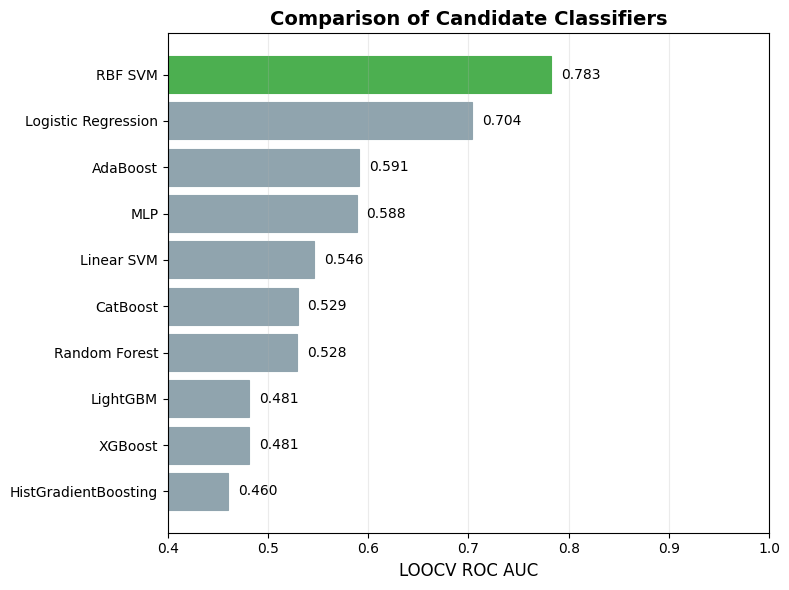

In [ ]:
model_names = list(loo_results.keys())
auc_scores = [loo_results[m]["auc"] for m in model_names]

order = np.argsort(auc_scores)

model_names = np.array(model_names)[order]
auc_scores = np.array(auc_scores)[order]

plt.figure(figsize=(8,6))

bars = plt.barh(
    model_names,
    auc_scores,
    edgecolor='black',
    linewidth=0.8
)

# Highlight best model

for bar,name in zip(bars,model_names):

    if name==best_name:
        bar.set_color("#4CAF50")
    else:
        bar.set_color("#90A4AE")

# Write values

for y,v in enumerate(auc_scores):

    plt.text(
        v+0.01,
        y,
        f"{v:.3f}",
        va="center",
        fontsize=10
    )

plt.xlim(0.4,1.0)

plt.xlabel("LOOCV ROC AUC",fontsize=12)

plt.title(
    "Comparison of Candidate Classifiers",
    fontsize=14,
    weight="bold"
)

plt.grid(axis='x',alpha=.25)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Figure_ModelComparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

2. Precision Recall Curve

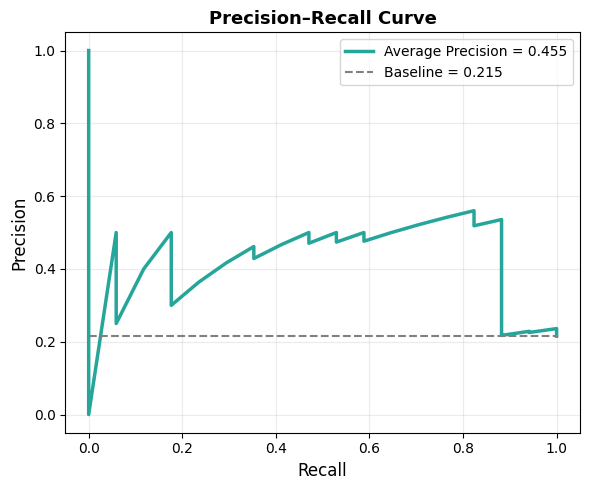

In [ ]:
precision, recall, thresholds = precision_recall_curve(
    y_train,
    best_probas
)

ap = average_precision_score(
    y_train,
    best_probas
)

plt.figure(figsize=(6,5))

plt.plot(
    recall,
    precision,
    color="#26A69A",
    lw=2.5,
    label=f"Average Precision = {ap:.3f}"
)

baseline = np.mean(y_train)

plt.hlines(
    baseline,
    0,
    1,
    colors="gray",
    linestyles="--",
    label=f"Baseline = {baseline:.3f}"
)

plt.xlabel("Recall",fontsize=12)

plt.ylabel("Precision",fontsize=12)

plt.title(
    "Precision–Recall Curve",
    fontsize=13,
    weight="bold"
)

plt.grid(alpha=.25)

plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Figure_PRCurve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

3. Calibration Curve

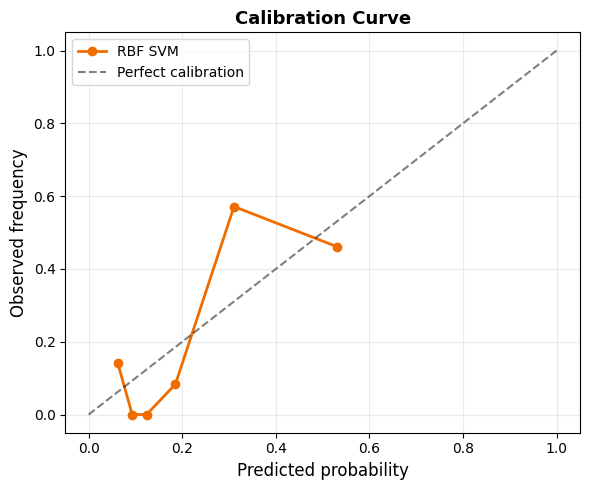

In [ ]:
prob_true, prob_pred = calibration_curve(
    y_train,
    best_probas,
    n_bins=6,
    strategy="quantile"
)

plt.figure(figsize=(6,5))

plt.plot(
    prob_pred,
    prob_true,
    "o-",
    color="#EF6C00",
    lw=2,
    label="RBF SVM"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black",
    alpha=.5,
    label="Perfect calibration"
)

plt.xlabel(
    "Predicted probability",
    fontsize=12
)

plt.ylabel(
    "Observed frequency",
    fontsize=12
)

plt.title(
    "Calibration Curve",
    fontsize=13,
    weight="bold"
)

plt.grid(alpha=.25)

plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Figure_Calibration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

4. Bootstrap ROC AUC

In [ ]:
#The Calculation

N_BOOTSTRAPS = 5000
rng = np.random.default_rng(42)

boot_aucs = []

y_true = np.asarray(y_train)
y_score = np.asarray(best_probas)

for _ in range(N_BOOTSTRAPS):
    idx = rng.integers(0, len(y_true), len(y_true))
    if len(np.unique(y_true[idx])) < 2:
        continue
    boot_aucs.append(
        roc_auc_score(
            y_true[idx],
            y_score[idx]
        )
    )

boot_aucs = np.array(boot_aucs)

lower = np.percentile(boot_aucs,2.5)
upper = np.percentile(boot_aucs,97.5)

LOOCV ROC AUC = 0.783
95% CI = [0.631, 0.907]


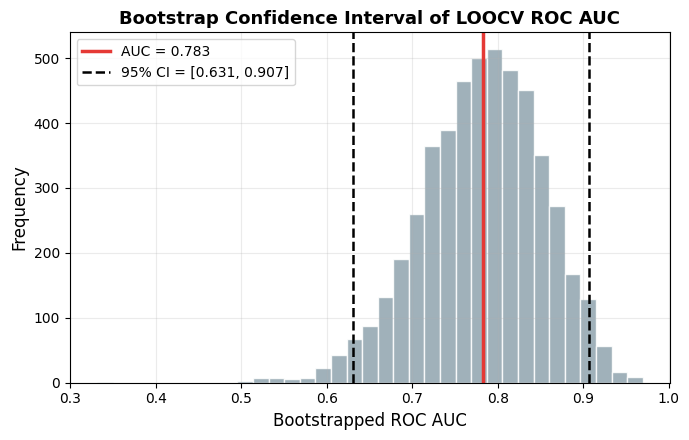

In [ ]:
#The Plot

plt.figure(figsize=(7,4.5))

plt.hist(
    boot_aucs,
    bins=35,
    color="#90A4AE",
    edgecolor="white",
    alpha=.85
)

plt.axvline(
    best_auc,
    color="#E53935",
    lw=2.5,
    label=f"AUC = {best_auc:.3f}"
)

plt.axvline(
    lower,
    color="black",
    ls="--",
    lw=1.8,
    label=f"95% CI = [{lower:.3f}, {upper:.3f}]"
)

plt.axvline(
    upper,
    color="black",
    ls="--",
    lw=1.8
)

plt.xlabel("Bootstrapped ROC AUC",fontsize=12)

plt.ylabel("Frequency",fontsize=12)

plt.title(
    "Bootstrap Confidence Interval of LOOCV ROC AUC",
    fontsize=13,
    weight="bold"
)

plt.grid(alpha=.25)

plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Figure_BootstrapCI.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

5. Decision Curve Analysis

In [ ]:
#The Calculation

thresholds = np.linspace(0.01,0.99,99)

net_benefit_model = []

N = len(y_train)

for t in thresholds:
    pred = (best_probas >= t).astype(int)
    TP = np.sum((pred==1)&(y_train==1))
    FP = np.sum((pred==1)&(y_train==0))
    nb = (TP/N) - (FP/N)*(t/(1-t))
    net_benefit_model.append(nb)

net_benefit_model = np.array(net_benefit_model)
prevalence = np.mean(y_train)
net_benefit_all = prevalence - (1-prevalence)*(thresholds/(1-thresholds))
net_benefit_none = np.zeros_like(thresholds)

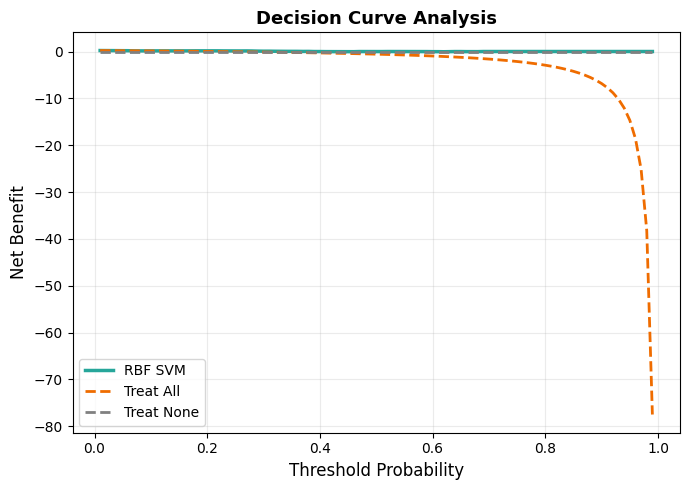

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    thresholds,
    net_benefit_model,
    color="#26A69A",
    lw=2.5,
    label=best_name
)

plt.plot(
    thresholds,
    net_benefit_all,
    "--",
    color="#EF6C00",
    lw=2,
    label="Treat All"
)

plt.plot(
    thresholds,
    net_benefit_none,
    "--",
    color="gray",
    lw=2,
    label="Treat None"
)

plt.xlabel(
    "Threshold Probability",
    fontsize=12
)

plt.ylabel(
    "Net Benefit",
    fontsize=12
)

plt.title(
    "Decision Curve Analysis",
    fontsize=13,
    weight="bold"
)

plt.grid(alpha=.25)

plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Figure_DCA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

6. Feature Importance

In [ ]:
#The background dataset
result = permutation_importance(
    best_pipe,
    X_train,
    y_train,
    scoring="roc_auc",
    n_repeats=100,
    random_state=42,
    n_jobs=-1
)

importance = result.importances_mean
std = result.importances_std

order = np.argsort(importance)

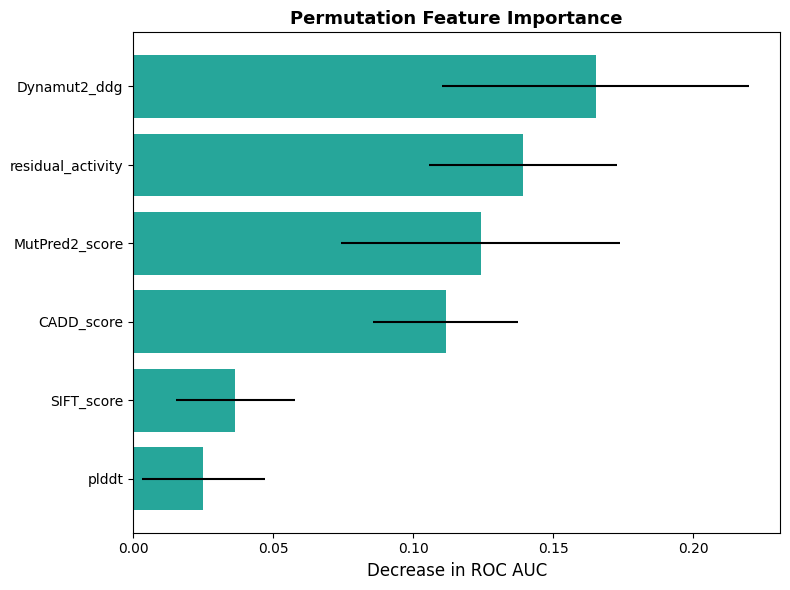

In [ ]:
#The plot
plt.figure(figsize=(8,6))

plt.barh(
    X_train.columns[order],
    importance[order],
    xerr=std[order],
    color="#26A69A"
)

plt.xlabel(
    "Decrease in ROC AUC",
    fontsize=12
)

plt.title(
    "Permutation Feature Importance",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Figure_PermutationImportance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

7. Learning Curve

In [ ]:
#The Calculation
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=best_pipe,
    X=X_train,
    y=y_train,
    cv=LeaveOneOut(),
    scoring="roc_auc",
    train_sizes=np.linspace(0.2,1.0,8),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = np.nanmean(train_scores,axis=1)
train_std  = np.nanstd(train_scores,axis=1)

valid_mean = np.nanmean(valid_scores,axis=1)
valid_std  = np.nanstd(valid_scores,axis=1)

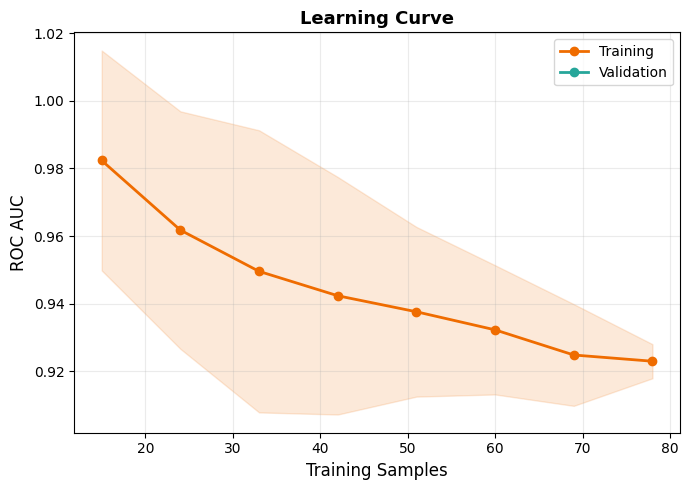

In [ ]:
#The plot
plt.figure(figsize=(7,5))

plt.plot(
    train_sizes,
    train_mean,
    'o-',
    lw=2,
    color="#EF6C00",
    label="Training"
)

plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=.15,
    color="#EF6C00"
)

plt.plot(
    train_sizes,
    valid_mean,
    'o-',
    lw=2,
    color="#26A69A",
    label="Validation"
)

plt.fill_between(
    train_sizes,
    valid_mean-valid_std,
    valid_mean+valid_std,
    alpha=.15,
    color="#26A69A"
)

plt.xlabel("Training Samples",fontsize=12)

plt.ylabel("ROC AUC",fontsize=12)

plt.title(
    "Learning Curve",
    fontsize=13,
    weight="bold"
)

plt.grid(alpha=.25)

plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Figure_LearningCurve.png",
    dpi=300
)

plt.show()

8. Feature Correlation Heatmap

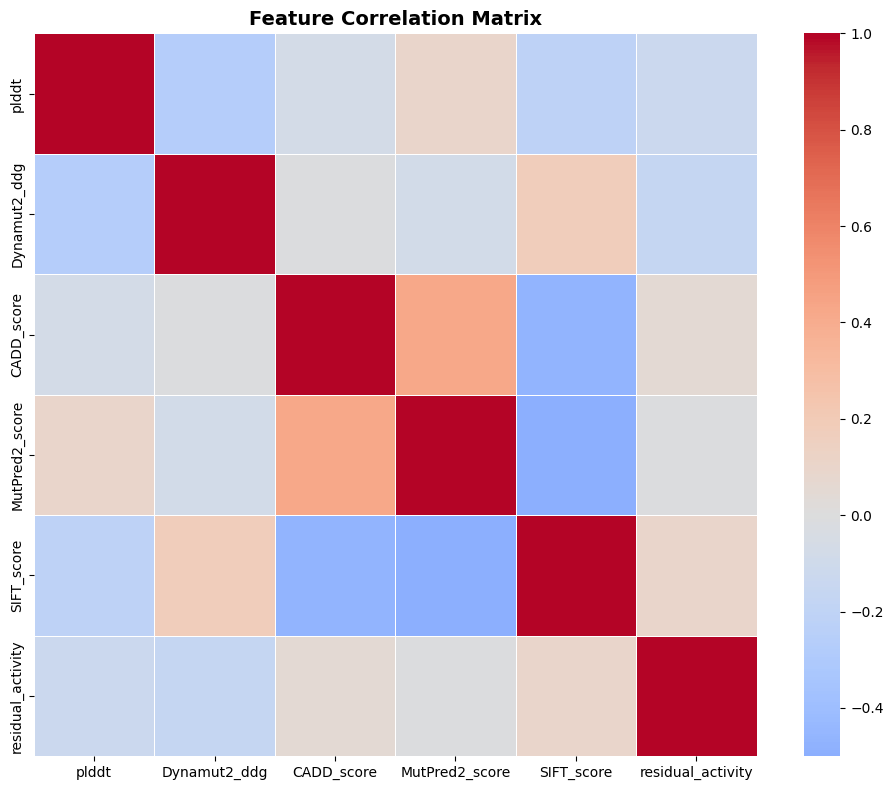

In [ ]:
corr = X_train.corr(method="spearman")

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidth=.5
)

plt.title(
    "Feature Correlation Matrix",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Figure_CorrelationHeatmap.png",
    dpi=300
)

plt.show()

9. Predicted Probability Distribution

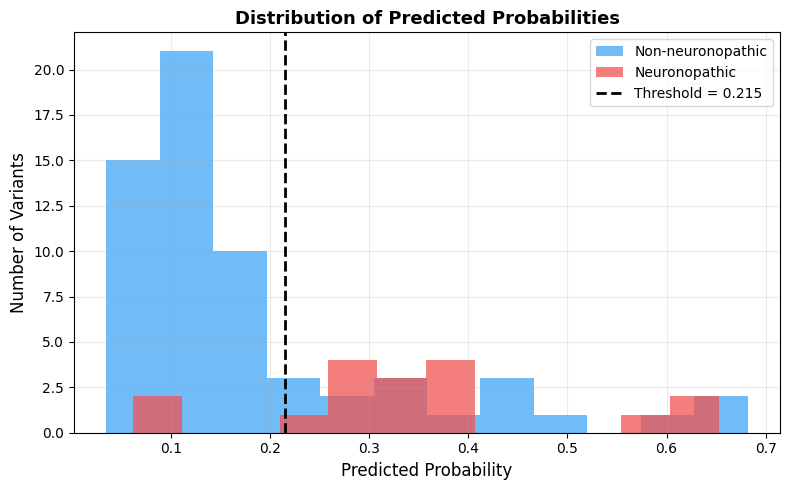

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    best_probas[y_train==0],
    bins=12,
    alpha=.75,
    label="Non-neuronopathic",
    color="#42A5F5"
)

plt.hist(
    best_probas[y_train==1],
    bins=12,
    alpha=.75,
    label="Neuronopathic",
    color="#EF5350"
)

plt.axvline(
    prior,
    color="black",
    ls="--",
    lw=2,
    label=f"Threshold = {prior:.3f}"
)

plt.xlabel(
    "Predicted Probability",
    fontsize=12
)

plt.ylabel(
    "Number of Variants",
    fontsize=12
)

plt.title(
    "Distribution of Predicted Probabilities",
    fontsize=13,
    weight="bold"
)

plt.legend()

plt.grid(alpha=.25)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Figure_ProbabilityDistribution.png",
    dpi=300
)

plt.show()